# Outcome vs. Process Reward Models

## ORM vs. PRM


There are two fundamental ways to judge a reasoning trace:

```text
[ Prompt: "Solve 2x + 5 = 13" ]
                │
                ▼
[ Step 1: "2x = 13 - 5" ] ──┐
                │          │
                ▼          ├──► Intermediate Steps
[ Step 2: "2x = 8" ]       ──┤
                │          │
                ▼          │
[ Step 3: "x = 4" ]        ──┘
                │
                ▼
[ Final Answer: "4" ] ───► Outcome
```

## Core Idea

- The reasoning path is judged at two different levels:
  - the final answer, or
  - each intermediate step.


## The Fundamental Credit Assignment Problem

### Outcome Reward Model (ORM)

An ORM evaluates only the final answer after the entire sequence is generated.

Given a prompt $X$ and a generated trajectory $Y = (s_1, s_2, \dots, s_T)$, the ORM outputs a single scalar score:

$$R(X, Y) \in \mathbb{R}$$

### Problem with ORM

- It suffers from sparse rewards and credit assignment collapse.
- If a subtle error appears in one step but is later cancelled out, the whole path may still receive a reward.
- Conversely, if most of the reasoning is correct but one late arithmetic mistake occurs, the entire trajectory can be penalized equally.

### Process Reward Model (PRM)

A PRM evaluates each intermediate reasoning step $s_t$ as it is generated.

It assigns a step-level reward:

$$r_t = R(X, s_{\le t}) \in [0, 1]$$

at the boundary of each step delimiter, such as a newline or explicit step marker.

### Advantage of PRM

- It provides dense supervision.
- It offers explicit error localization by identifying the exact step where the reasoning chain breaks down.


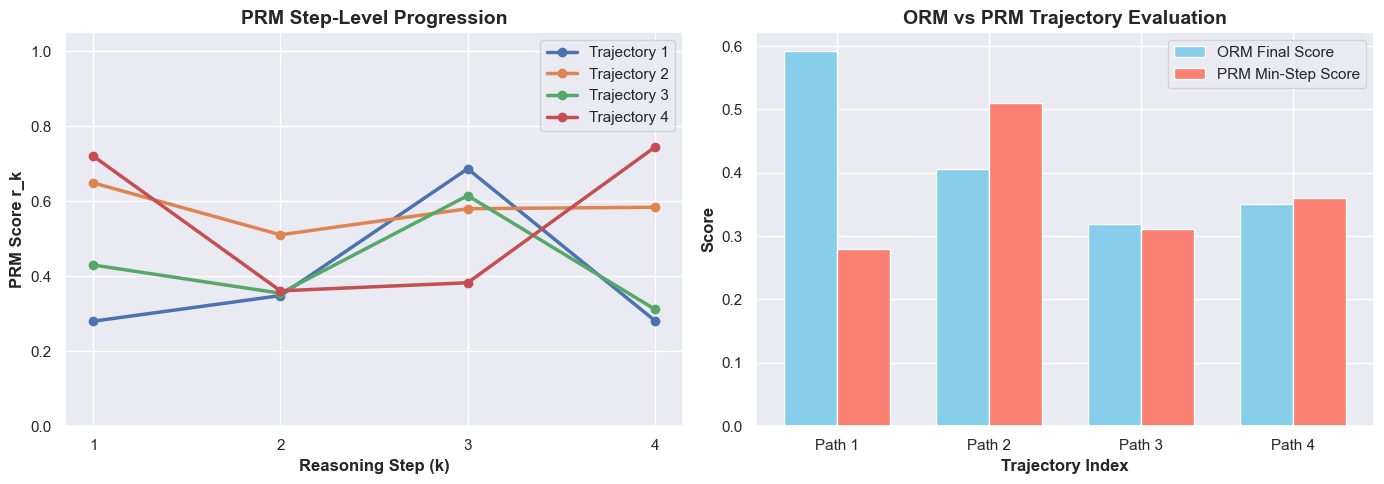

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

torch.manual_seed(42)

class OutcomeRewardModel(nn.Module):
    """
    ORM Head: Takes the final token hidden state and maps to a single scalar.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.v_head = nn.Linear(hidden_dim, 1)

    def forward(self, hidden_states):
        # hidden_states: [batch_size, seq_len, hidden_dim]
        final_token_state = hidden_states[:, -1, :] # [batch_size, hidden_dim]
        score = self.v_head(final_token_state) # [batch_size, 1]
        return torch.sigmoid(score)


class ProcessRewardModel(nn.Module):
    """
    PRM Head: Scores intermediate steps by evaluating states at step delimiters.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.v_head = nn.Linear(hidden_dim, 1)

    def forward(self, hidden_states, step_indices_mask):
        """
        hidden_states: [batch_size, seq_len, hidden_dim]
        step_indices_mask: [batch_size, seq_len] (Boolean mask, True at step boundaries)
        """
        scores = torch.sigmoid(self.v_head(hidden_states)).squeeze(-1) # [batch_size, seq_len]
        
        # Mask out non-delimiter tokens
        step_scores = scores * step_indices_mask.float()
        return step_scores


# --- SIMULATION & COMPARATIVE VISUALIZATION ---
hidden_dim = 128
batch_size = 4 # 4 candidate trajectories
seq_len = 20

# Mock hidden states from a transformer
hidden_states = torch.randn(batch_size, seq_len, hidden_dim)

# Step mask: Steps end at indices 4, 9, 14, 19
step_mask = torch.zeros(batch_size, seq_len, dtype=torch.bool)
step_mask[:, [4, 9, 14, 19]] = True

orm = OutcomeRewardModel(hidden_dim)
prm = ProcessRewardModel(hidden_dim)

orm_scores = orm(hidden_states).detach().squeeze().numpy()
prm_step_scores = prm(hidden_states, step_mask).detach().numpy()

# Extract only step delimiter scores for each path
prm_path_scores = []
for b in range(batch_size):
    delim_scores = prm_step_scores[b, step_mask[b]]
    prm_path_scores.append(delim_scores)

prm_path_scores = np.array(prm_path_scores) # Shape: [4 trajectories, 4 steps]
prm_min_scores = prm_path_scores.min(axis=-1) # Worst-step score per trajectory

# Plotting Comparison
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PRM Step-by-Step Trajectory Scores
for i in range(batch_size):
    axes[0].plot(range(1, 5), prm_path_scores[i], marker='o', linewidth=2.5, label=f'Trajectory {i+1}')

axes[0].set_xlabel('Reasoning Step (k)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('PRM Score r_k', fontsize=12, fontweight='bold')
axes[0].set_title('PRM Step-Level Progression', fontsize=14, fontweight='bold')
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# Plot 2: ORM vs PRM Min Aggregation Ranking
x_indices = np.arange(batch_size)
width = 0.35

axes[1].bar(x_indices - width/2, orm_scores, width, label='ORM Final Score', color='skyblue')
axes[1].bar(x_indices + width/2, prm_min_scores, width, label='PRM Min-Step Score', color='salmon')

axes[1].set_xlabel('Trajectory Index', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('ORM vs PRM Trajectory Evaluation', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_indices)
axes[1].set_xticklabels([f'Path {i+1}' for i in range(batch_size)])
axes[1].legend()

plt.tight_layout()
plt.show()

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class StepWisePRM(nn.Module):
    """
    Process Reward Model that scores individual reasoning steps.
    """
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.encoder = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids: torch.Tensor, step_delimiter_id: int):
        """
        input_ids: [batch_size, seq_len]
        step_delimiter_id: Token ID marking step boundaries (e.g., '\n' or '<<step>>')
        """
        embeds = self.embedding(input_ids) # [batch_size, seq_len, embed_dim]
        hidden_states, _ = self.encoder(embeds) # [batch_size, seq_len, hidden_dim]
        
        # Calculate raw step scores
        logits = self.value_head(hidden_states).squeeze(-1) # [batch_size, seq_len]
        step_probs = torch.sigmoid(logits)

        # Locate step delimiter positions
        delimiter_mask = (input_ids == step_delimiter_id) # [batch_size, seq_len]

        return step_probs, delimiter_mask

    def evaluate_trajectories(self, input_ids: torch.Tensor, step_delimiter_id: int):
        """
        Scores paths based on worst-step probability (min-step rule).
        """
        step_probs, delimiter_mask = self.forward(input_ids, step_delimiter_id)
        batch_size = input_ids.shape[0]
        
        path_scores = []
        for b in range(batch_size):
            step_indices = delimiter_mask[b].nonzero(as_tuple=True)[0]
            if len(step_indices) == 0:
                # Fallback to final token if no delimiter present
                score = step_probs[b, -1].item()
            else:
                # Extract scores at step boundaries
                scores_at_steps = step_probs[b, step_indices]
                score = torch.min(scores_at_steps).item() # Min aggregation
            
            path_scores.append(score)
            
        return path_scores


# --- VERIFICATION EXECUTION ---
if __name__ == "__main__":
    vocab_size = 500
    step_delimiter_id = 99 # ID representing step boundary
    
    prm_model = StepWisePRM(vocab_size=vocab_size, embed_dim=32, hidden_dim=64)
    
    # 3 sampled trajectories for a single prompt
    # Trajectory 1: Valid logic across all steps
    # Trajectory 2: Flawed step in middle
    # Trajectory 3: Invalid start step
    traj_1 = torch.tensor([12, 45, 67, 99, 10, 20, 30, 99, 5, 15, 25, 99])
    traj_2 = torch.tensor([12, 45, 67, 99, 400, 401, 99, 5, 15, 25, 99])
    traj_3 = torch.tensor([1, 2, 99, 10, 20, 30, 99, 50, 60, 70, 99])

    # Pad sequences to match length
    max_len = max(len(traj_1), len(traj_2), len(traj_3))
    padded_trajs = torch.zeros(3, max_len, dtype=torch.long)
    padded_trajs[0, :len(traj_1)] = traj_1
    padded_trajs[1, :len(traj_2)] = traj_2
    padded_trajs[2, :len(traj_3)] = traj_3

    # Score trajectories
    scores = prm_model.evaluate_trajectories(padded_trajs, step_delimiter_id)
    
    print("=== Step-Wise PRM Trajectory Scoring ===")
    for idx, sc in enumerate(scores):
        print(f"Candidate Path {idx+1} PRM Min Score: {sc:.4f}")
        
    best_path_idx = torch.argmax(torch.tensor(scores)).item()
    print(f"\n[PRM Selection] Selected Trajectory {best_path_idx+1} for execution.")

=== Step-Wise PRM Trajectory Scoring ===
Candidate Path 1 PRM Min Score: 0.4582
Candidate Path 2 PRM Min Score: 0.4456
Candidate Path 3 PRM Min Score: 0.4746

[PRM Selection] Selected Trajectory 3 for execution.
